In [1]:
import pyabf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
laser_ma = {8: 500, 9: 700, 10: 900, 11: 1000, 12: 1100, 13: 1200, 14: 1400}
archivos = [8, 9, 10, 11, 12, 13, 14]
fases = ["control", "laser", "rec"]
colores  = {"control": "#1a6fad", "laser": "#c0392b", "rec": "#2e7d32"}

ruta_base = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\27042026 patch"
ruta_analisis = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\ANÁLISIS"

FASE_DURACION = 150

archivos_info = {
    8:  {"control": (0, 163.1), "laser": (163.1, 314.8), "rec": (314.8, 480.0)},
    9:  {"control": (0, 154.3), "laser": (154.3, 310.3), "rec": (310.3, 480.0)},
    10: {"control": (0, 155.6), "laser": (155.6, 311.4), "rec": (311.4, 480.0)},
    11: {"control": (0, 152.1), "laser": (152.1, 304.9), "rec": (304.9, 480.0)},
    12: {"control": (0, 156.4), "laser": (156.4, 314.4), "rec": (314.4, 480.0)},
    13: {"control": (0, 153.7), "laser": (153.7, 314.3), "rec": (314.3, 480.0)},
    14: {"control": (0, 152.9), "laser": (152.9, 307.8), "rec": (307.8, 480.0)},
}

## Visualización de las ventanas AHP: del segundo al quinto sexto de pulso

Restringimos el análisis a los APs que caen entre el 2º y el 5º sexto de cada pulso de corriente para un análisis fiable. Esto excluye los APs del inicio y del final del pulso, donde la membrana todavía está en tránsito por la inyección de corriente y las ventanas de reposo quedan contaminadas.

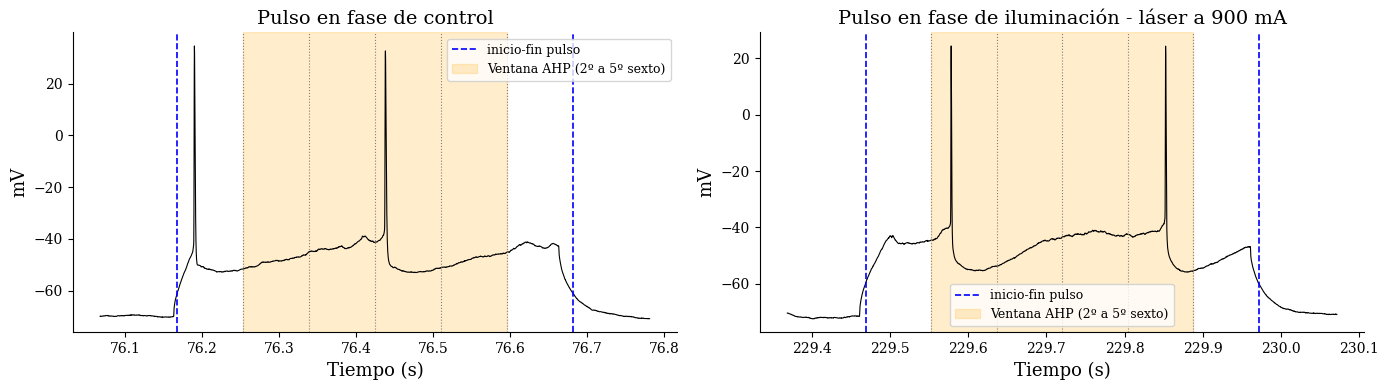

In [3]:
plt.rcParams['font.family']  = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

abf = pyabf.ABF(rf"{ruta_base}\26427010.abf")
abf.setSweep(0, channel=0)
tiempo = abf.sweepX
vm = abf.sweepY
fs = abf.dataRate

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, fase, titulo in zip(axes, ["control", "laser"],
                                   ["Pulso en fase de control",
                                    "Pulso en fase de iluminación - láser a 900 mA"]):
    t0  = archivos_info[10][fase][0]
    mask = (tiempo >= t0) & (tiempo <= t0 + FASE_DURACION)
    t_fase = tiempo[mask]
    vm_fase = vm[mask]

    reposo = np.median(vm_fase)
    umbral = reposo + 10
    por_encima = (vm_fase > umbral).astype(int)
    flancos_subida = np.where(np.diff(por_encima)== 1)[0]
    flancos_bajada = np.where(np.diff(por_encima)== -1)[0]

    pulsos = []
    i = 0
    while i < len(flancos_subida):
        t_ini = t_fase[flancos_subida[i]]
        bajadas_validas = flancos_bajada[flancos_bajada > flancos_subida[i]]
        if len(bajadas_validas) > 0:
            pulsos.append((flancos_subida[i], bajadas_validas[0]))
        i += 1
        while i < len(flancos_subida) and t_fase[flancos_subida[i]] - t_ini < 2.0:
            i += 1

    ini_idx, fin_idx = pulsos[len(pulsos) // 2]
    t_ini = t_fase[ini_idx]
    t_fin = t_fase[fin_idx]
    dur = t_fin - t_ini

    margen = 0.1
    mask_zoom = (t_fase >= t_ini - margen) & (t_fase <= t_fin + margen)

    ax.plot(t_fase[mask_zoom], vm_fase[mask_zoom], color='black', linewidth=0.8)
    ax.axvline(t_ini, color='blue', linewidth=1.2, linestyle='--', label='inicio-fin pulso')
    ax.axvline(t_fin, color='blue', linewidth=1.2, linestyle='--')
    for k in range(1, 6):
        ax.axvline(t_ini + k * dur / 6, color='gray', linewidth=0.8, linestyle=':')
    ax.axvspan(t_ini + dur / 6, t_ini + 5 * dur / 6,
               color='orange', alpha=0.2, label='Ventana AHP (2º a 5º sexto)')

    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel('Tiempo (s)', fontsize=13)
    ax.set_ylabel('mV', fontsize=13)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Cálculo de la AHP

AHP= diferencia entre el mínimo de voltaje en una ventana de 50 ms tras el pico (excluyendo los primeros 3 ms de repolarización rápida) y el potencial de reposo local. El reposo local se estima como la media del voltaje en la ventana [-8ms, -5ms] antes del pico.

In [4]:
datos_ahp = {num: {fase: [] for fase in fases} for num in archivos}

for num in archivos:
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    abf.setSweep(0, channel=0)
    tiempo = abf.sweepX
    vm = abf.sweepY
    fs = abf.dataRate

    w_reposo_fin = int(5 * fs / 1000)
    w_reposo_dur = int(3* fs / 1000)
    w_ahp = int(50 * fs / 1000)

    for fase in fases:
        t0 = archivos_info[num][fase][0]
        mask = (tiempo >= t0) & (tiempo <= t0 + FASE_DURACION)
        t_fase = tiempo[mask]
        vm_fase = vm[mask]

        reposo = np.median(vm_fase)
        umbral = reposo + 10
        por_encima = (vm_fase > umbral).astype(int)
        flancos_subida = np.where(np.diff(por_encima)== 1)[0]
        flancos_bajada = np.where(np.diff(por_encima) == -1)[0]

        pulsos = []
        i = 0
        while i < len(flancos_subida):
            t_ini = t_fase[flancos_subida[i]]
            bajadas_validas = flancos_bajada[flancos_bajada > flancos_subida[i]]
            if len(bajadas_validas) > 0:
                pulsos.append((flancos_subida[i], bajadas_validas[0]))
            i += 1
            while i < len(flancos_subida) and t_fase[flancos_subida[i]] - t_ini < 2.0:
                i += 1

        picos, _ = find_peaks(vm_fase, height=0, distance=int(0.05 * fs))

        for ini_idx, fin_idx in pulsos:
            duracion  = fin_idx - ini_idx
            lim_ini = ini_idx + duracion/6
            lim_fin = ini_idx + 5 * duracion/6

            picos_centrales = [p for p in picos if lim_ini <= p <= lim_fin]

            for p in picos_centrales:
                if p - w_reposo_fin - w_reposo_dur < 0 or p + w_ahp >= len(vm_fase):
                    continue
                reposo_local = np.mean(vm_fase[p - w_reposo_fin - w_reposo_dur : p - w_reposo_fin])
                minimo_ahp = np.min(vm_fase[p + int(3 * fs / 1000) : p + w_ahp])
                datos_ahp[num][fase].append(minimo_ahp - reposo_local)

# Tabla resumen
filas = []
for num in archivos:
    for fase in fases:
        vals = datos_ahp[num][fase]
        filas.append({
            "archivo": num,
            "intensidad (mA)": laser_ma[num],
            "fase": fase,
            "media (mV)": round(np.mean(vals),   2) if vals else np.nan,
            "std (mV)": round(np.std(vals),    2) if vals else np.nan,
            "mediana (mV)": round(np.median(vals), 2) if vals else np.nan,
            "n APs": len(vals),
        })

df_ahp = pd.DataFrame(filas)
df_ahp

,archivo,intensidad (mA),fase,media (mV),std (mV),mediana (mV),n APs
0,8,500,control,-11.33,1.12,-11.46,90
1,8,500,laser,-13.45,1.21,-13.52,90
2,8,500,rec,-14.29,1.18,-14.32,42
3,9,700,control,-16.27,0.00,-16.27,1
4,9,700,laser,-15.89,1.40,-15.99,7
5,9,700,rec,-14.05,1.41,-14.02,28
6,10,900,control,-13.43,1.29,-13.33,41
7,10,900,laser,-14.98,1.01,-14.96,53
8,10,900,rec,-12.00,1.22,-11.90,41
9,11,1000,control,-10.72,1.10,-10.64,46


## Boxplot de AHP por archivo

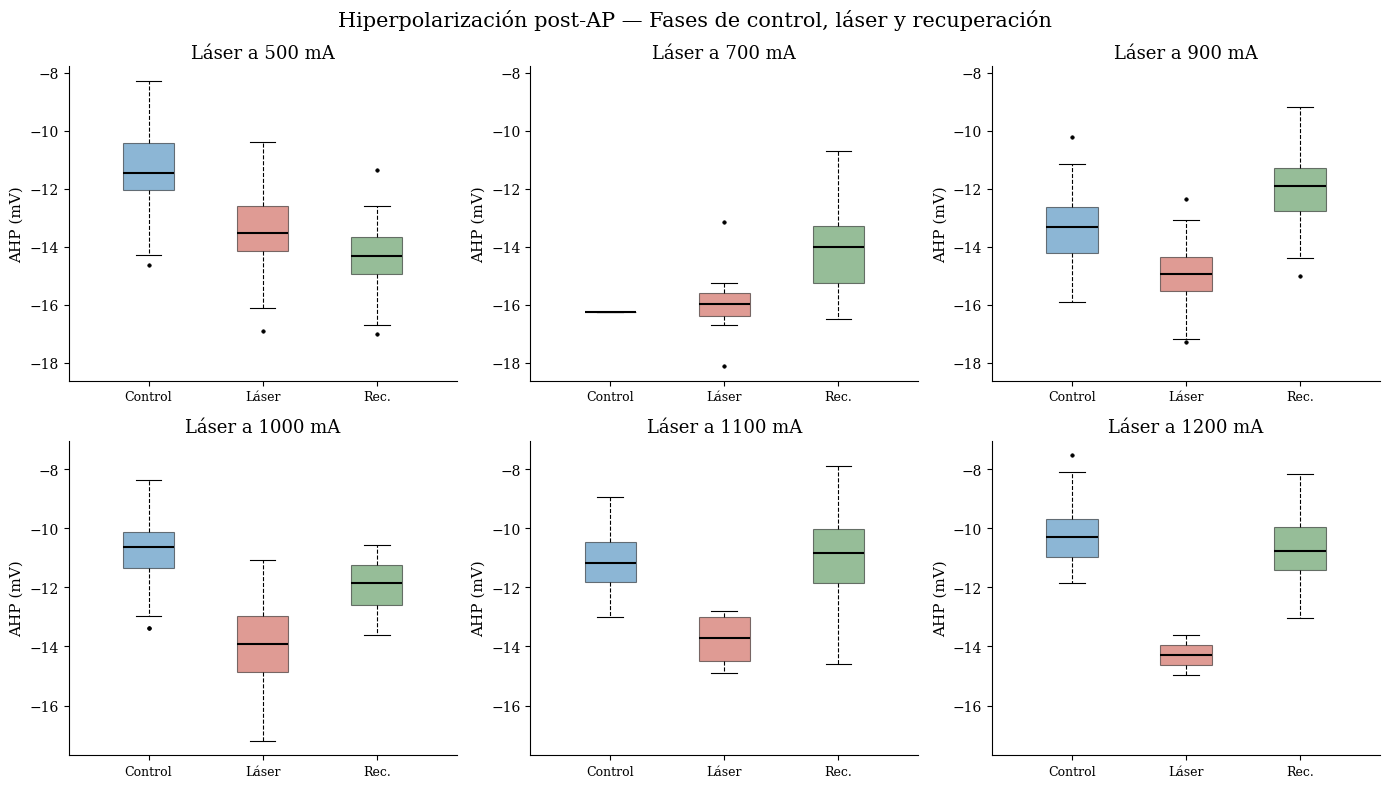

In [6]:
archivos_plot = [8, 9, 10, 11, 12, 13]

ymin_fila = {0: np.inf,  1: np.inf}
ymax_fila = {0: -np.inf, 1: -np.inf}
for idx, n in enumerate(archivos_plot):
    fila = idx // 3
    for fase in fases:
        vals = datos_ahp[n][fase]
        if vals:
            ymin_fila[fila] = min(ymin_fila[fila], np.min(vals))
            ymax_fila[fila] = max(ymax_fila[fila], np.max(vals))
for fila in [0, 1]:
    rng = ymax_fila[fila] - ymin_fila[fila]
    ymin_fila[fila] -= rng * 0.05
    ymax_fila[fila] += rng * 0.05

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, n in enumerate(archivos_plot):
    fila = idx // 3
    ax = axes[fila][idx % 3]
    datos = [datos_ahp[n][fase] if datos_ahp[n][fase] else [np.nan] for fase in fases]

    bp = ax.boxplot(datos, positions=[1, 2, 3], widths=0.45,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(linewidth=0.8, color='black', linestyle='--'),
                    capprops=dict(linewidth=0.8, color='black'),
                    boxprops=dict(linewidth=0.8),
                    flierprops=dict(marker='o', markersize=2.5, linestyle='none',
                                    markeredgewidth=0.5, markeredgecolor='black'))

    for patch, fase in zip(bp['boxes'], fases):
        patch.set_facecolor(colores[fase])
        patch.set_alpha(0.5)
        patch.set_edgecolor('black')

    for flier in bp['fliers']:
        flier.set_markerfacecolor('black')

    ax.set_ylim(ymin_fila[fila], ymax_fila[fila])
    ax.set_title(f"Láser a {laser_ma[n]} mA", fontsize=13)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Control', 'Láser', 'Rec.'], fontsize=9)
    ax.set_xlim(0.3, 3.7)
    ax.set_ylabel("AHP (mV)", fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Hiperpolarización post-AP — Fases de control, láser y recuperación", fontsize=15)
plt.tight_layout()
plt.show()